First 5 Rows
                            Uniq Id            Crawl Timestamp  \
0  10d8b81dc693db8a3f92e19254525d53  2020-03-17 02:32:10 +0000   
1  31ef1ee4961d3fcff33e363edd7677eb  2020-03-17 02:32:10 +0000   
2  6943e517922b051cbec496be32fbb57f  2020-03-17 02:32:10 +0000   
3  6778c794e6ac7112981d4ebb239d6826  2020-03-17 02:32:10 +0000   
4  2335a28ae24db3b2191080bfd98a86e0  2020-03-17 02:32:10 +0000   

                    Billing Uniq Id  Rating  \
0  c697dc43961526785292107b91a639e1     NaN   
1  c697dc43961526785292107b91a639e1     NaN   
2  c697dc43961526785292107b91a639e1     NaN   
3  c697dc43961526785292107b91a639e1     NaN   
4  c697dc43961526785292107b91a639e1     NaN   

                                        Review Title  Review Rating  \
0                           Best Natural Deodorant!!            5.0   
1          Schmidt's Charcoal Deodorant is the best!            5.0   
2                  Beware. Defective or counterfeit.            1.0   
3  Good for infrequent 

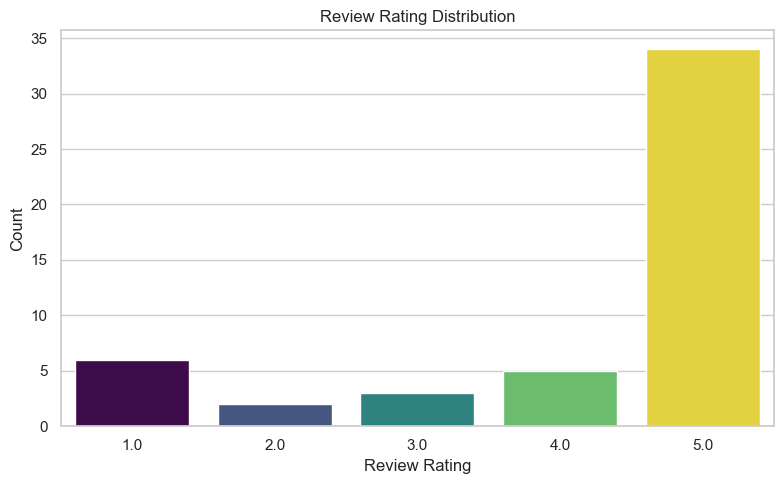

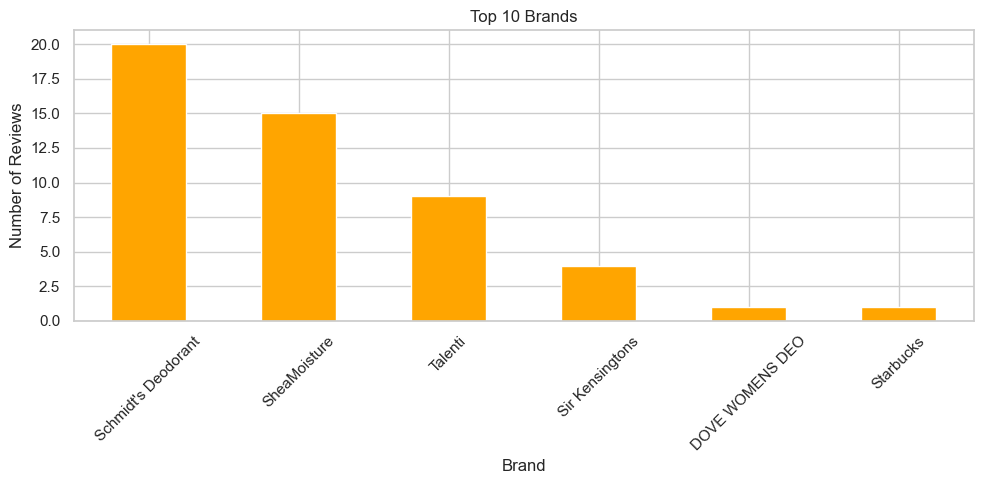

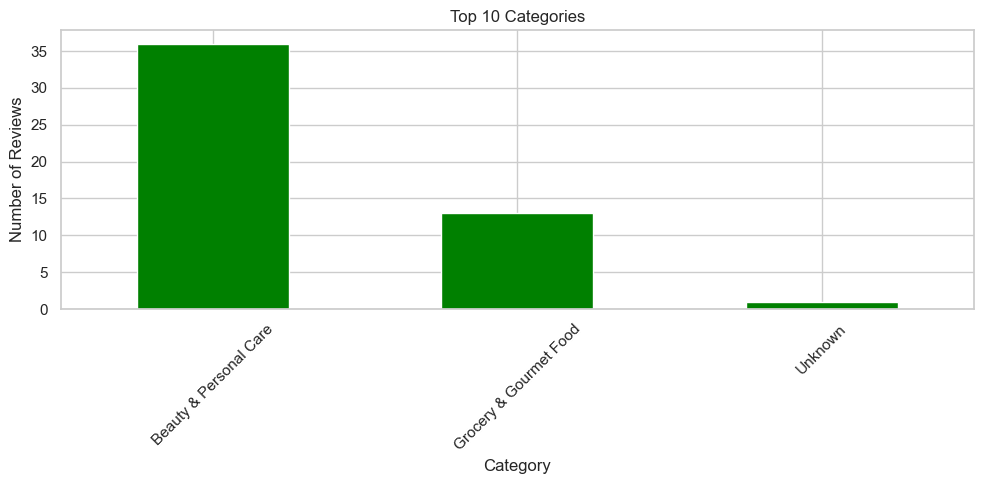

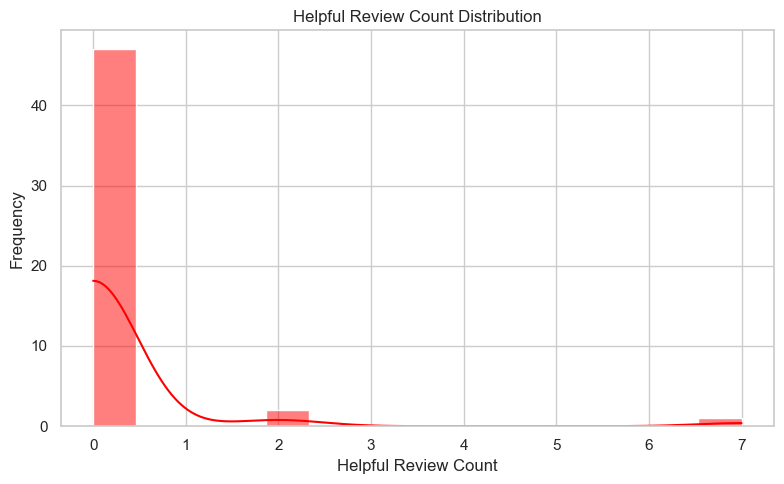


Top 10 Helpful Reviews
                            Review Title                Brand  Review Rating  \
14  Wow Rapid Delivery and great product      DOVE WOMENS DEO            5.0   
22                   Perfect and unisex!  Schmidt's Deodorant            5.0   
44                            Addictive!              Talenti            5.0   
0               Best Natural Deodorant!!  Schmidt's Deodorant            5.0   
28                           Moisturizer         SheaMoisture            5.0   
29                    Great for the skin         SheaMoisture            5.0   
30              This is my favorite soap         SheaMoisture            5.0   
31       It will dried your skin a a lot         SheaMoisture            1.0   
32                          Good Product         SheaMoisture            5.0   
33   Don’t like the large slender seeds.         SheaMoisture            4.0   

    Helpful Review Count  
14                   7.0  
22                   2.0  
44            

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

df = pd.read_csv(r"C:\Users\Admin\Downloads\archive\amazon_com-product_reviews__20200101_20200331_sample.csv")

print("First 5 Rows")
print(df.head())

print("\nShape of Dataset:", df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
df.info()

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

if "Billing Uniq Id" in df.columns:
    df.drop("Billing Uniq Id", axis=1, inplace=True)

if "Url" in df.columns:
    df.drop("Url", axis=1, inplace=True)

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = df[col].fillna(0)

if "Review Date" in df.columns:
    df["Review Date"] = pd.to_datetime(df["Review Date"], errors="coerce")

if "Helpful Review Count" in df.columns:
    df["Helpful Review Count"] = pd.to_numeric(df["Helpful Review Count"], errors="coerce").fillna(0)

if "Review Content" in df.columns:
    df["Review Length"] = df["Review Content"].astype(str).apply(len)

print("\nDescriptive Statistics")
print(df.describe())

print("\nCategorical Statistics")
print(df.describe(include="object"))

print("\nAverage Review Rating")
print(df["Review Rating"].mean())

print("\nTop 10 Brands")
print(df["Brand"].value_counts().head(10))

print("\nTop 10 Categories")
print(df["Category"].value_counts().head(10))

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Review Rating", hue="Review Rating", palette="viridis", legend=False)
plt.title("Review Rating Distribution")
plt.xlabel("Review Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
df["Brand"].value_counts().head(10).plot(kind="bar", color="orange")
plt.title("Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
df["Category"].value_counts().head(10).plot(kind="bar", color="green")
plt.title("Top 10 Categories")
plt.xlabel("Category")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["Helpful Review Count"], bins=15, kde=True, color="red")
plt.title("Helpful Review Count Distribution")
plt.xlabel("Helpful Review Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("\nTop 10 Helpful Reviews")
print(df.sort_values(by="Helpful Review Count", ascending=False)[["Review Title","Brand","Review Rating","Helpful Review Count"]].head(10))

df.to_csv("Cleaned_Amazon_Product_Reviews.csv", index=False)

print("\nAnalysis Completed Successfully")
print("Cleaned dataset saved as Cleaned_Amazon_Product_Reviews.csv")